# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 5. Нейронные сети.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
      * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/thetagrader"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"> **ThetaGrader**</a>. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 60 баллов;
* Задача 2 &mdash; 60 баллов;
* Задача 3 &mdash; 70 баллов.

In [ ]:
# Bot check

# HW_ID: fpmi_ad5
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [298]:

from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

from torchvision import transforms
from torchvision.datasets import MNIST
import torch.nn as nn
import torch.nn.functional
from IPython.display import clear_output
import random

sns.set_theme(palette="Set2", font_scale=1.2)

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. https://chatgpt.com/share/69be93ba-3aa0-8008-bc91-5d77cded60c2


**Задача 2**
1. https://chatgpt.com/share/69be9432-1eb8-8008-8e10-e0d7a97dd7d6
    - оформление


---

### Задача 1.

Обратимся вновь к уже знакомому нам по первому занятию датасету **MNIST**. Как вы помните, этот набор данных содержит изображения рукописных цифр, каждое из которых имеет размер **28x28**. Всего в датасете содержится **60 000** изображений в обучающей выборке и еще **10 000** — в тестовой.

В этой домашней работе мы немного упростим данные, а именно:
* сожмем изображения в два раза по каждой из размерностей, то есть до **14x14**,
* оставим **10 000** изображений в обучающей выборке.

> *Примечание.* При желании вы можете усложнить данные &mdash; отказаться от сжатия изображений и/или увеличить количество данных. Однако учтите, что в таком случае модели будут работать дольше, и, возможно, вам будет сложнее достичь желаемых результатов.

**Наша задача остается прежней:** *по изображению определить, какая цифра на нем нарисована.*
На этот раз мы будем решать ее с помощью простых нейронных сетей. Также мы заглянем "под капот" нейросетей, чтобы лучше понять процесс их обучения.

> *Примечание.* Обычно подобные задачи, связанные с изображениями, решаются с помощью сверточных нейронных сетей, которые лучше подходят для работы с изображениями. Они станут темой наших следующих занятий, ждем всех!

Ниже представлена готовая функция для загрузки и предварительной обработки данных.
В рамках этой функции мы выполняем следующие шаги.
* Загрузка исходных данных.
* Сохранение **10 000** изображений в качестве обучающей выборки.
* Сжатие изображений в два раза по каждой из осей, что приводит к размеру **14x14**..
* Растягиваем изображение размером **14x14** в вектор длиной $14 \cdot 14 = 196$. Более подробно эта операция описана на первом занятии.

In [18]:
def load_mnist(
    train_size: int = 10_000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels

Загрузим данные и посмотрим на их размерности

In [19]:
train_images, train_labels, test_images, test_labels = load_mnist()

print("Train:", train_images.shape, train_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

Train: torch.Size([10000, 196]) torch.Size([10000])
Test: torch.Size([10000, 196]) torch.Size([10000])



**1.** Используя `Sequential` подход в PyTorch, напишите модель нейронной сети по следующему описанию.

* **Вход**: изображение в виде вектора.
* **Два линейных слоя** с промежуточной размерностью 64.
* **Функция активации**: между линейными слоями используется `ReLU`, а на выходе второго слоя — отсутствует (или используется тождественная функция).
* **Выход**: вектор логитов размером 10, соответствующий количеству классов.

> Эта нейронная сеть для изображения $x$ оценивает вектор логитов $\left(\ell_0(x),..., \ell_9(x)\right)$ принадлежности к каждому из классов, аналогично логистической регрессии. Имея оценку логитов $\left(\ell_0(x),..., \ell_9(x)\right)$ , можно получить оценку вероятности $p_k$ для каждого класса по следующей формуле, используя softmax-функцию (обобщение логистической сигмоиды)
> $$
\widehat{p}_k(x) = \frac{\exp\left(\widehat{\ell}_k(x)\right)}{\exp\left(\widehat{\ell}_0(x)\right) +... + \exp\left(\widehat{\ell}_9(x)\right)},
$$
> которая реализуется с помощью функции `nn.functional.softmax(..., dim=-1)`. В качестве оценки класса можно взять класс с наибольшей вероятностью, что можно реализовать с помощью метода `argmax(axis=...)` у тензора в PyTorch.

In [313]:
model = nn.Sequential(
    nn.Linear(in_features= 14 * 14, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features= 64, out_features=10),
)



**2.** **Напишите цикл обучения нейросети**, используя кросс-энтропию `nn.CrossEntropyLoss()` качестве лосс-функции. Это обобщение бинарной кросс-энтропии, которую мы рассматривали на лекции по логистической регрессии. Ее реализация в PyTorch принимает на вход логиты (что и возвращает наша нейросеть) и истинные метки классов. Обучайте сеть на полном наборе данных с помощью метода градиентного спуска `torch.optim.SGD`, не разбивая данные на случайные батчи (как это делается в SGD).


Примерно каждые 5-10 итераций выполняйте следующие действия:

* Получите текущие предсказания классов для обучающей и тестовой выборок.
* Посчитайте точность (accuracy) классификации для этих выборок.
* Постройте график зависимости точности классификации от номера итерации (от начала обучения до текущей итерации) для обучающей и тестовой выборок. Перед построением графика используйте `clear_output(wait=True)` для плавной очистки холста в процессе обновления графика. Посмотрите примеры в ноутбуке с занятия.
* Сохраните следующие значения:
    * Значение лосс-функции.
    * Точность классификации для обучающей и тестовой выборок.
    * Матрицы весов для каждого слоя.

*Замечания:*
* Рекомендуем сохранять данные в заранее подготовленный словарь, ключи которого соответствуют именам переменных (например, `"weights_layer_2"`), а значения словаря представляют собой списки значений этих переменных по итерациям.
* При сохранении не забывайте вызывать метод `.detach().numpy()` для преобразования матриц в массивы numpy. Также может потребоваться заново инициализировать матрицы с помощью `np.array(...)`, чтобы сохранить сами матрицы, а не ссылки на них, по которым значения меняются в процессе обучения сети.

Выполните 10 000 итераций обучения. Сколько времени это заняло?

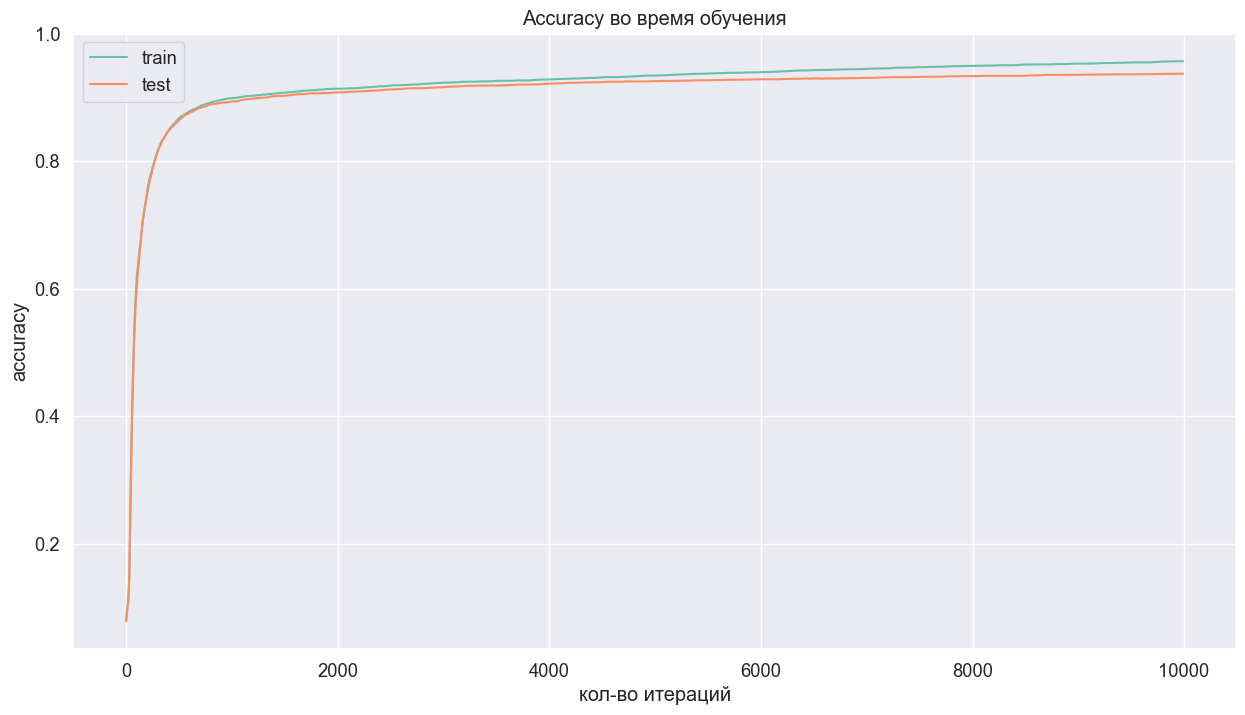

In [314]:
def train_model(model, train_images, train_labels, test_images, test_labels,
                num_iter=10000, lr=0.05):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    history = {
        'loss': [],
        'train_acc': [],
        'test_acc': [],
        'weights_layer_1': [],
        'weights_layer_2': [],
        'iters': []
    }

    for i in range(num_iter):
        logits = model(train_images)
        loss = loss_fn(logits, train_labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if i % 10 == 0:
            clear_output(wait=True)

            train_logits = model(train_images)
            test_logits = model(test_images)

            train_pred = train_logits.argmax(dim=-1)
            test_pred = test_logits.argmax(dim=-1)

            train_acc = (train_pred == train_labels).float().mean().item()
            test_acc = (test_pred == test_labels).float().mean().item()

            history['loss'].append(loss.item())
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            history['iters'].append(i)

            history['weights_layer_1'].append(model[0].weight.detach().numpy().copy())
            history['weights_layer_2'].append(model[2].weight.detach().numpy().copy())

            plt.figure(figsize=(15, 8))
            plt.plot(history['iters'], history['train_acc'], label='train')
            plt.plot(history['iters'], history['test_acc'], label='test')
            plt.ylabel('accuracy')
            plt.xlabel('кол-во итераций')
            plt.title("Accuracy во время обучения")
            plt.legend()
            plt.show()

    return history

history = train_model(
    model,
    train_images, train_labels,
    test_images, test_labels,
    num_iter=10000,
    lr = 0.05
)

In [315]:
print('Итоговая train accuracy:', history['train_acc'][-1])
print('Итоговая test accuracy:', history['test_acc'][-1])

Итоговая train accuracy: 0.9567000269889832
Итоговая test accuracy: 0.9372000098228455


Проверьте себя, точность классификации на тестовой выборке должна быть около $90\%$. Если вы получили значительно меньший результат (менее $85\%$), попробуйте явно инициализировать веса сети и настроить разные значения `learning_rate` для разных параметров (посмотрите примеры с занятия). Если эти меры не помогут, то стоит поискать ошибку. Да, обучение нейронных сетей — это непростой процесс.

In [316]:
...

Ellipsis


**3.** Теперь самое интересное &mdash; заглянем под капот нашей нейросети!

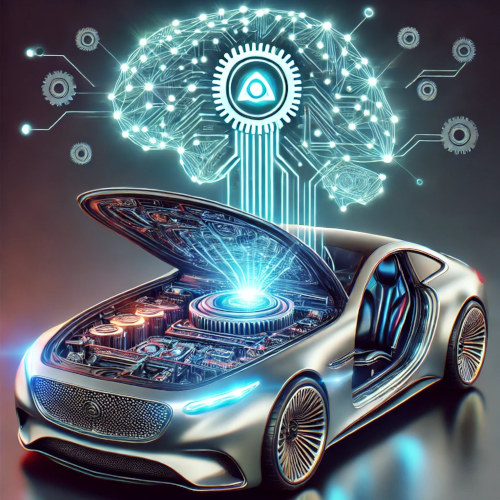

Для более глубокого понимания работы нейросети **визуализируем матрицы весов** для нескольких итераций обучения. Тем самым, вы сможете оценить, как меняется поведение модели в процессе обучения.

1. Выберите примерно 10 итераций обучения, включая первую и последнюю.
2. Для каждого слоя настройте график, используя предоставленный шаблон.

Обратите внимание, что для корректной визуализации матрицы весов ее необходимо **транспонировать**. Например, для первого слоя вертикальная ось должна соответствовать входу сети, а горизонтальная — промежуточной размерности.

В качестве цветовой палитры выбрана `"bwr"`, что позволяет отображать положительные числа матрицы красным цветом, а отрицательные — синим. Чтобы достичь этого, также **необходимо установить параметры `vmin` и `vmax`** симметрично относительно нуля, чтобы нули отображались белым цветом. Подберите эти значения таким образом, чтобы получить наиболее четкую картинку, на которой выделяются определенные группы пикселей.

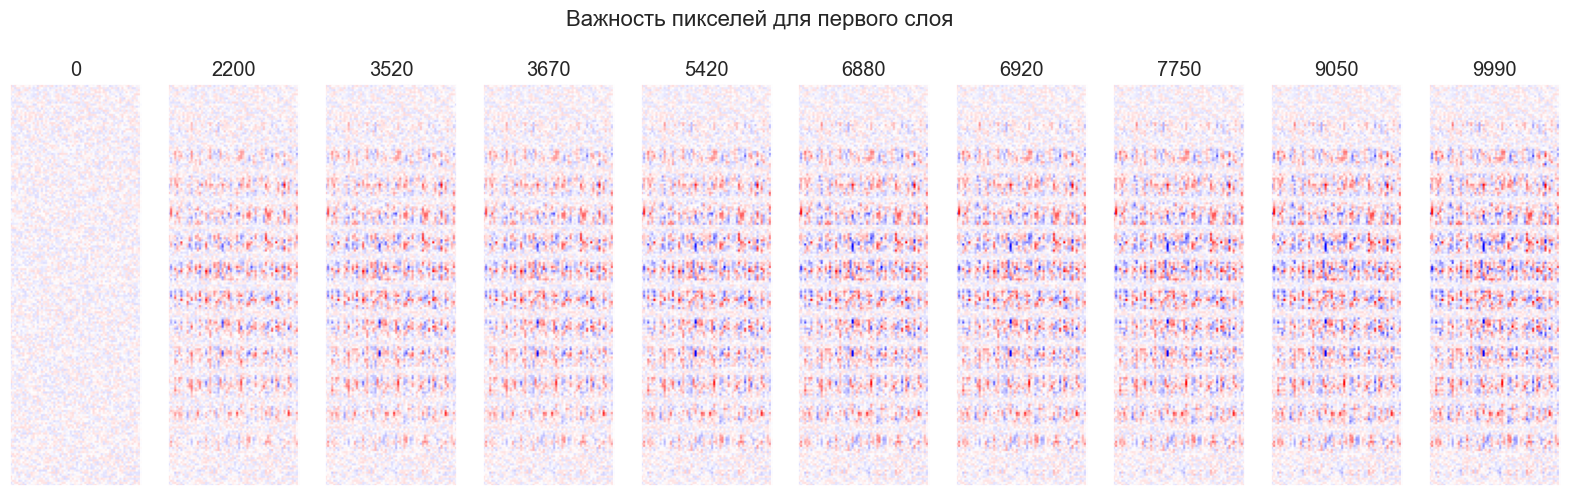

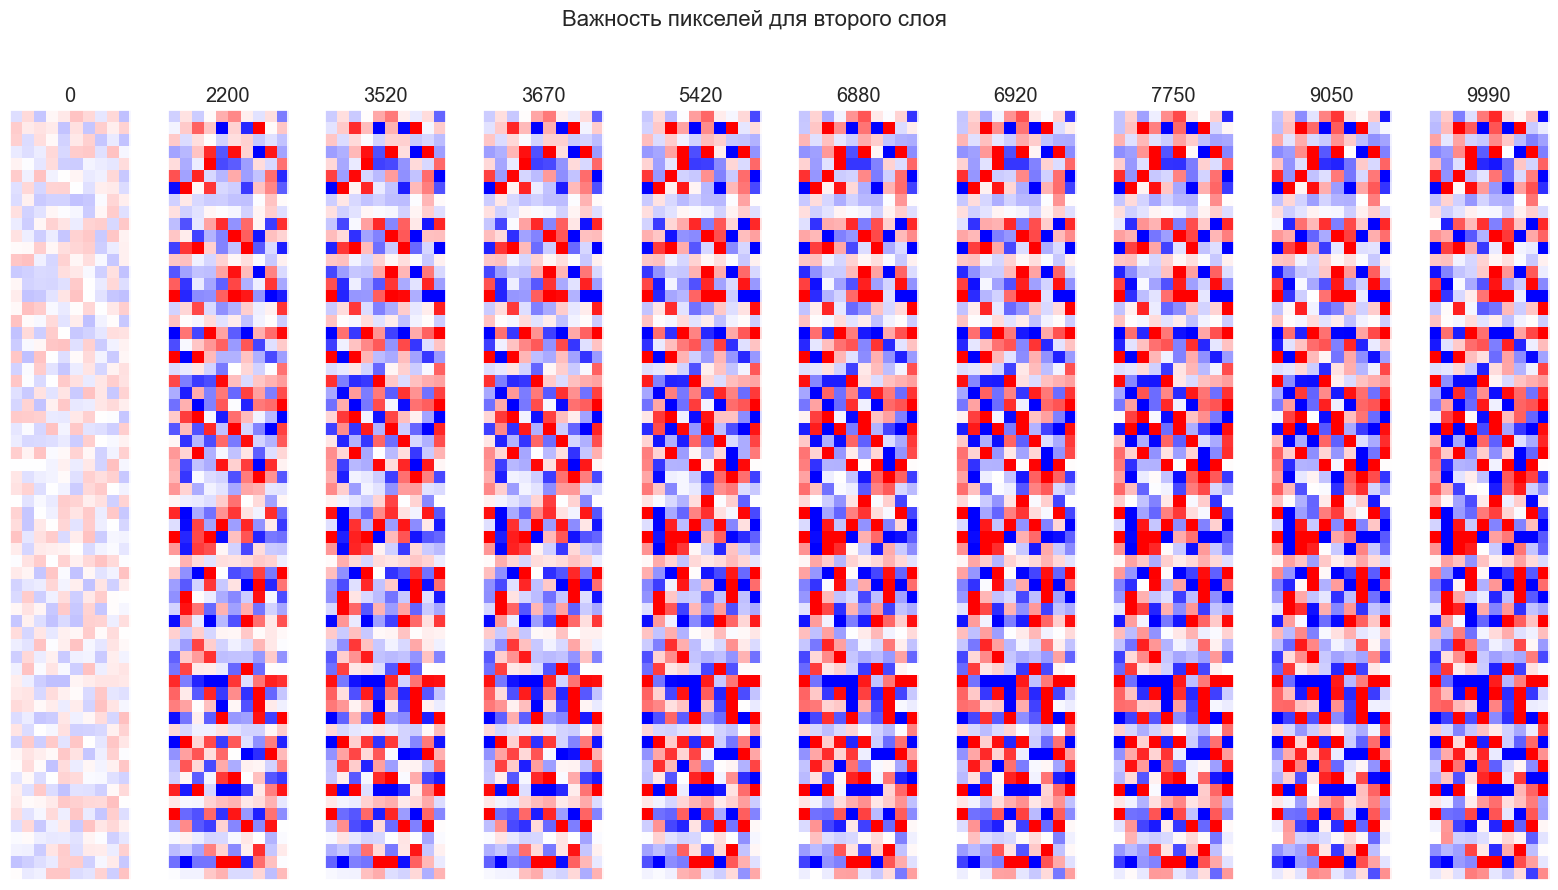

In [317]:
# Для каждого слоя

list_iter = [history['iters'][0]]

for i in range(8) :
    list_iter.append(random.choice(history['iters']))
list_iter.append(history['iters'][-1])

list_iter.sort()

plt.figure(figsize=(20, 10))
plt.suptitle("Важность пикселей для первого слоя", fontsize=16)

for i in range(1, 11):  # по выбранным итерациям
    it = list_iter[i - 1]
    plt.subplot(1, 10, i)  # для отображения всех итераций в ряд
    plt.imshow(history['weights_layer_1'][it // 10].T, cmap="bwr", vmin= -0.5, vmax= 0.5)  # настройте vmin = -vmax
    plt.title(f"{it}")  # укажите номер итерации
    plt.xticks([])  # уберем координаты по x
    plt.yticks([])  # уберем координаты по y

plt.subplots_adjust(top=1.3)
plt.show()


plt.figure(figsize=(20, 10))
plt.suptitle("Важность пикселей для второго слоя", fontsize=16)
for i in range(1, 11):  # по выбранным итерациям
    it = list_iter[i - 1]
    plt.subplot(1, 10, i)  # для отображения всех итераций в ряд
    plt.imshow(history['weights_layer_2'][it // 10].T, cmap="bwr", vmin= -0.5, vmax= 0.5)  # настройте vmin = -vmax
    plt.title(f"{it}")  # укажите номер итерации
    plt.xticks([])  # уберем координаты по x
    plt.yticks([])  # уберем координаты по y


plt.show()


Какие выводы можно сделать, основываясь на полученных визуализациях?
Подумайте, почему на больших итерациях для первого слоя начинают выделяться определенные пиксели? Почему именно эти пиксели?

*Подсказка: вспомните, как устроены входные изображения цифр, с которыми мы работаем.*

**Ответ:**

Некоторые цифры имеют паттерны рисования. Например, 8-ка или 2-ка затрагивают те пиксели, которые остальные цифра почти никогда не затаргивают, поэтому если этотпиксель закрашен с большой вероятностью это 2 или 8. Также и другие цифры имеют своми особенности и свои особенные пиксели
Также есть строчки котрые почти вообще белые, то есть это какие-то очень удаленные пиксели
По мере обучения в первом слое начинают выделяться пиксели, которые действительно несут информацию о форме цифры.
В целом визуализация показывает что сеть постепенно переходит от случайных весов к осмысленному выделению информативных областей.


**4.** Попробуйте **улучшить точность классификации**, рассмотрев больше нейронов в промежуточном слое.

In [318]:
model_2 = nn.Sequential(
    nn.Linear(in_features= 14 * 14, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features= 128, out_features=10),
)

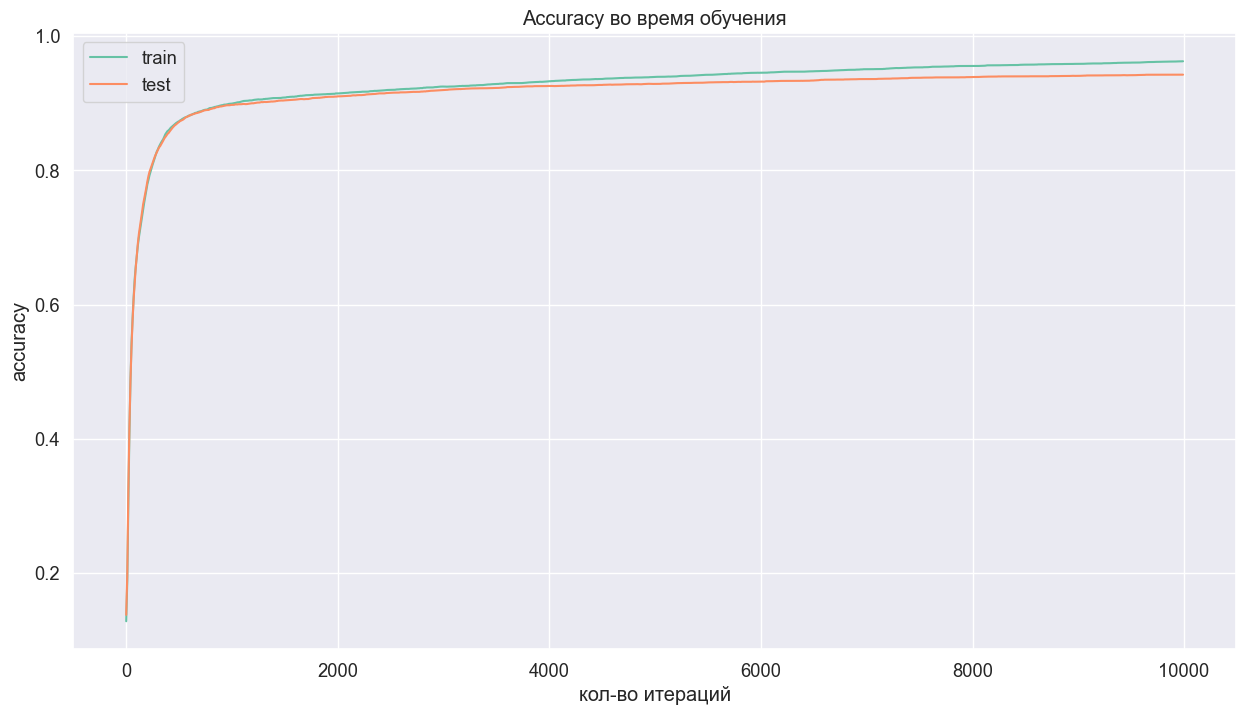

In [319]:
history_2 = train_model(
    model_2,
    train_images, train_labels,
    test_images, test_labels,
    num_iter=10000,
    lr=0.05
)

In [320]:
print('Итоговая train accuracy:', history_2['train_acc'][-1])
print('Итоговая test accuracy:', history_2['test_acc'][-1])

Итоговая train accuracy: 0.9627000093460083
Итоговая test accuracy: 0.9427000284194946


Теперь попробуйте добавить к сети еще один слой.

In [328]:
model_3 = nn.Sequential(
    nn.Linear(in_features= 14 * 14, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features= 64, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features= 64, out_features=10),
)

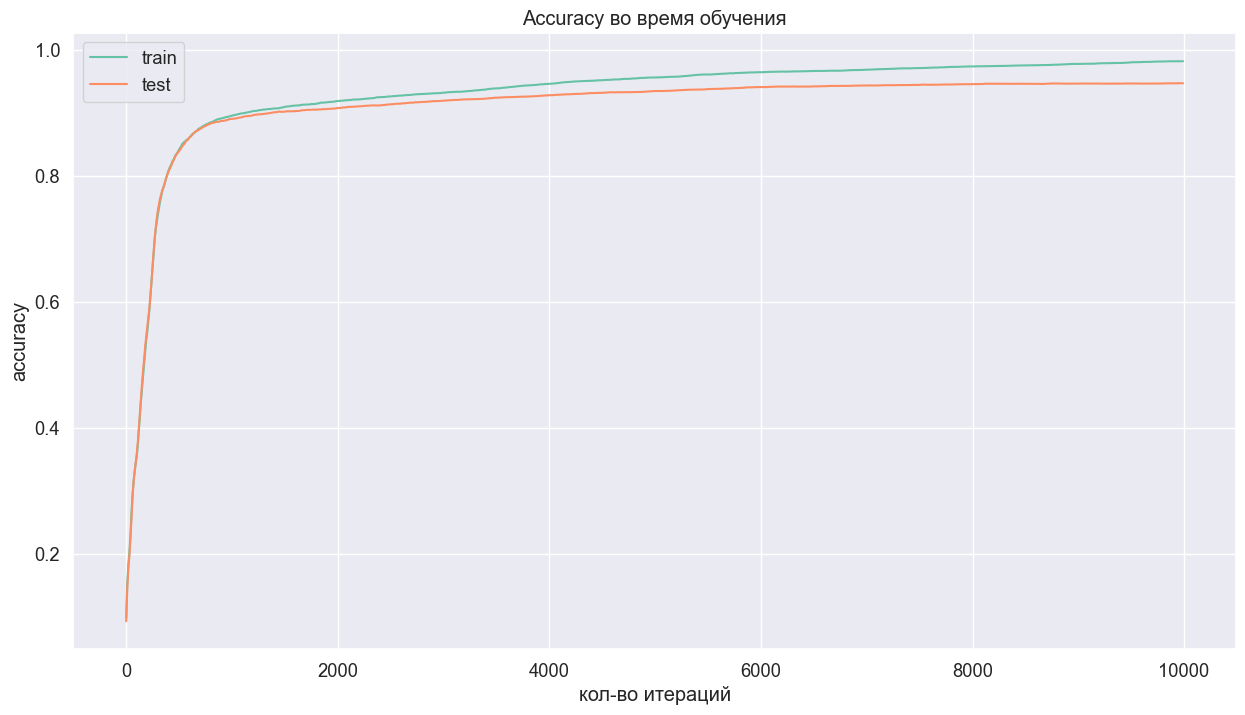

In [329]:
history_3 = train_model(
    model_3,
    train_images, train_labels,
    test_images, test_labels,
    num_iter=10000,
    lr=0.05
)

In [331]:
print('Итоговая train accuracy:', history_3['train_acc'][-1])
print('Итоговая test accuracy:', history_3['test_acc'][-1])

Итоговая train accuracy: 0.982699990272522
Итоговая test accuracy: 0.9477999806404114


Насколько дольше обучается нейросеть? Получилось ли улучшить качество?

**Ответ:**

Видно, что с увелечением количества нейронов и слоев время работы увеличивается (хоть и не сильно, хотя это может быть потому что мы не сильно увеличивали). Качестов получилось заметно улучшить, получился достаточно большой прирост точности в процентах, при небольшом увелечении времени

**5.** Сделайте выводы.

**Ответ:**

Простая двухслойная нейронная сеть уже хорошо решает задачу классификации MNIST и дает точность на тестовой выборке 93.7%. Увеличение числа нейронов в одном скрытом слое привело к улучшению качества. Кроме того, добавление еще одного скрытого слоя позволило повысить test accuracy примерно до 95% хоть обучение и стало дольше

---
### Задача 2.

**При решении задачи запрещено пользоваться ИИ-инструментами,** но можно при оформлении решения.


Рассмотрим *упрощенную* нейронную сеть с механизмом Attention, которая решает задачу анализа тональности текста. На вход сети поступает фраза, состоящая *ровно из двух слов*. Слова уже переведены в векторы (эмбеддинги) $x_1, x_2 \in \mathbb{R}^d$. Сеть должна предсказать вероятность того, что фраза имеет позитивный окрас. Для этого модель использует обучаемый вектор-запрос (Query) $q \in \mathbb{R}^d$, который «ищет», на какое из двух слов нужно обратить больше внимания.

Прямой проход нейросети выглядит следующим образом.

1. С помощью скалярного произведения оцениваем важности каждого слова:
$$z_1(x_1) = q^{\top} x_1, \quad z_2(x_2) = q^{\top} x_2$$

2. Получаем веса внимания с помощью функции Softmax:
$$\alpha_1(z_1, z_2) = \frac{e^{z_1}}{e^{z_1} + e^{z_2}}, \quad \alpha_2(z_1, z_2) = \frac{e^{z_2}}{e^{z_1} + e^{z_2}}$$

3. Формируем вектор контекста $c \in \mathbb{R}^d$ как взвешенную сумму слов:
$$c(x_1, x_2, \alpha_1, \alpha_2) = \alpha_1 x_1 + \alpha_2 x_2$$

4. Пропускаем контекст через линейный классификатор с логистической сигмоидой для получения оценки вероятности позитивного окраса фразы:
$$y_\theta(x_1, x_2) = f(c) = \sigma(w^{\top} c + b),$$
где $\theta$ &mdash; общий набор обучаемых параметров.

**1.** Нарисуйте схематически данную нейронную сеть в виде графа вычислений. Сколько у нее обучаемых параметров (размерность $\theta$)?

*Схему можно нарисовать от руки или в каком-либо редакторе. Для вставки изображения скопируйте его и вставьте в ячейку markdown с помощью `Ctrl+V`. Должно появится либо большое количество символов (Colab), либо что-то вроде `![image.png](attachment:image.png)`. Если этот способ не работает, можно загрузить картинку в коде и вывести ее в output ячейки.*

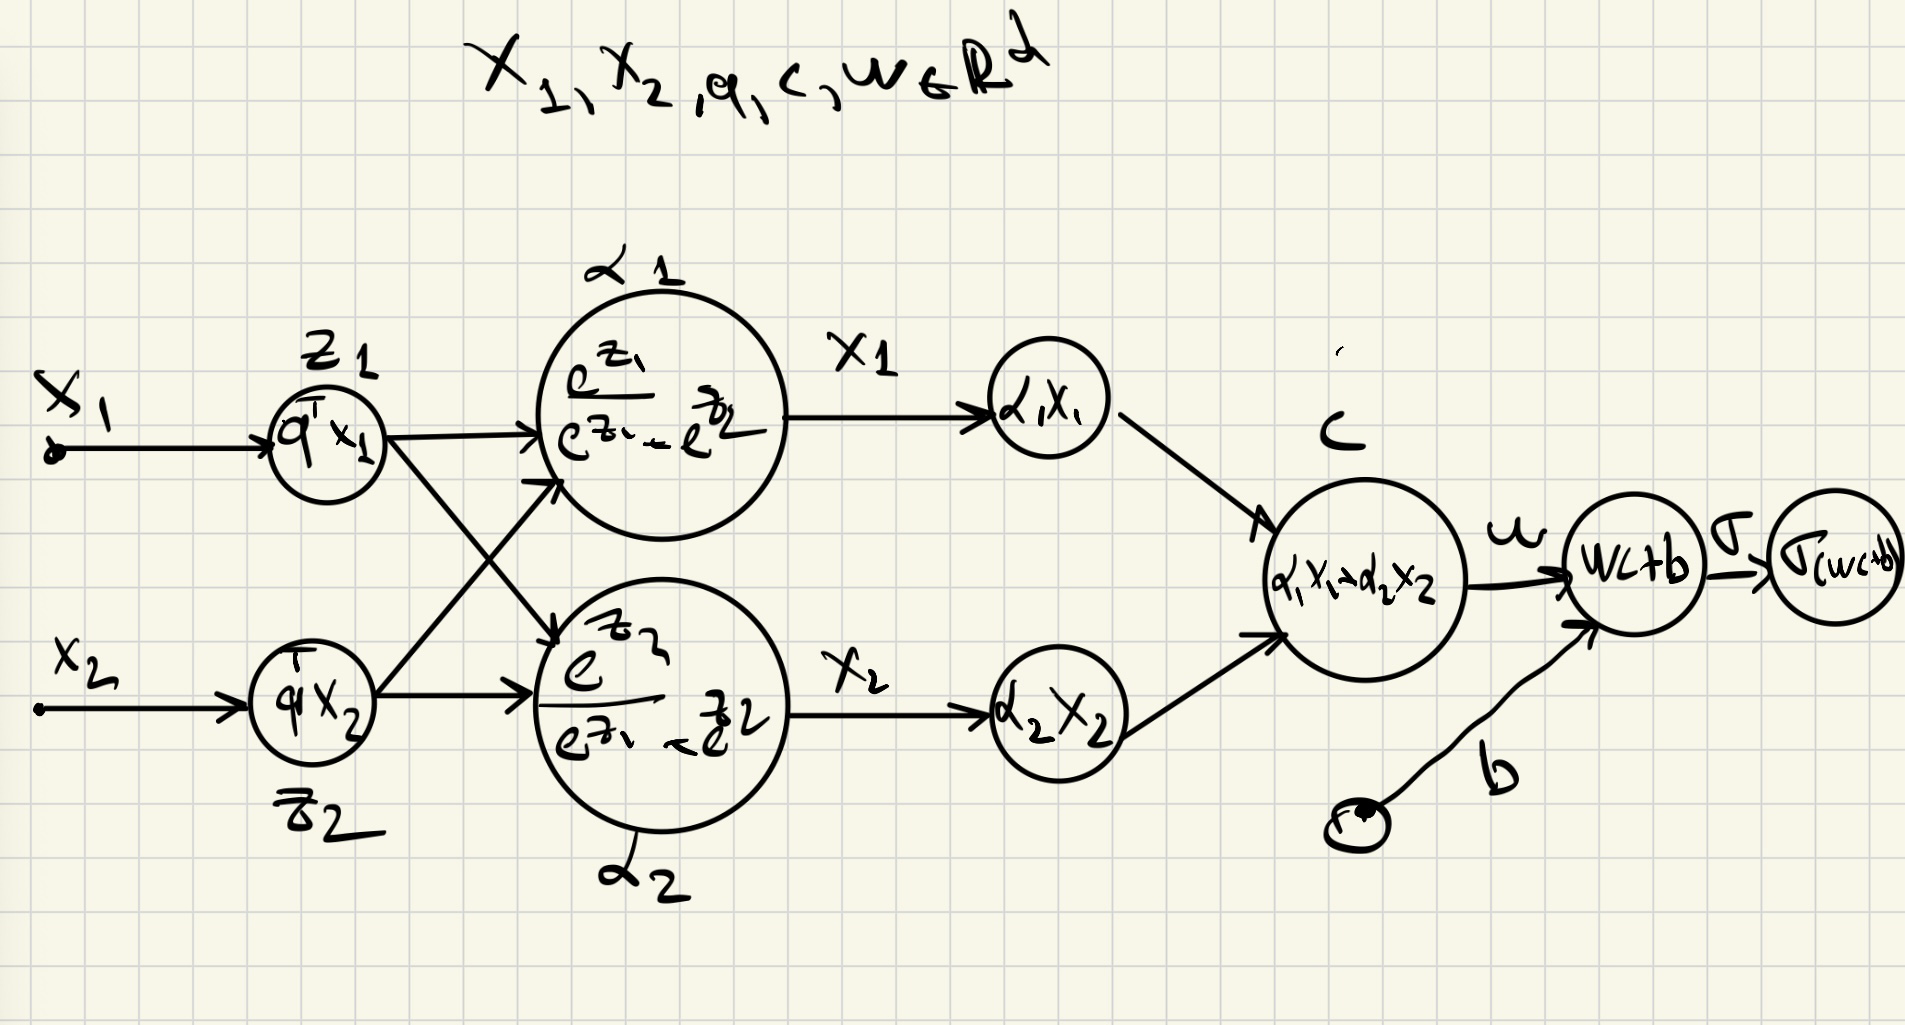

**2.** Дана обучающая выборка $X \in \mathbb{R}^{n \times 2d}$ — матрица входных данных и $Y \in \{0, 1\}^{n}$ — таргет. Нейронная сеть обучается по этой выборке, минимизируя заданную функцию $\mathscr{L}$, в данном случае рассмотрим кросс энтропию
$$\mathscr{L}(\theta) = -\sum_{i=1}^n \bigg[ Y_i \log y_\theta(x_{1i}, x_{2i}) + (1-Y_i) \log \big(1-y_\theta(x_{1i}, x_{2i})\big) \bigg].$$

Наша цель — определить оптимальные параметры нашей модели, минимизируя функцию $\mathscr{L}(\theta)$ на заданном наборе данных. Мы будем решать эту задачу с помощью метода градиентного спуска, который требует вычисления производных по всем параметрам сети. Конечно, в данном случае несложно выписать все производные напрямую, с чем каждый из вас легко сможет справиться.

Однако прямое вычисление производных имеет квадратичную зависимость от количества параметров, что делает его неэффективным. Из-за этого мы не смогли бы быстро обучать глубокие нейронные сети. Хотя в данном случае речь идёт всего лишь о двух слоях, понимание работы методов на простых примерах было бы полезно.

На лекции был рассказан метод **обратного распространения ошибки (back propagation)** и показан его пример для двухслойной нейронной сети (на доске). Выпишите все необходимые производные для применения метода back propagation.

$$
L(w)=L\bigl(\sigma\bigl(W(\alpha_1x_1+\alpha_2x_2)+b\bigr)\bigr)
$$

$$
L(\theta)=-\sum_{i=1}^n\Bigl[(1-Y_i)\log\bigl(1-y_\theta(x_{1i},x_{2i})\bigr)+Y_i\log y_\theta(x_{1i},x_{2i})\Bigr]
$$

$$
\begin{cases}
\dfrac{\partial L(\theta)}{\partial y_{3i}}
=
-\dfrac{Y_i}{y_{3i}}+\dfrac{1-Y_i}{1-y_{3i}},\\[1.2em]
\dfrac{\partial y_{3i}}{\partial y_{2i}}
=
y_{3i}(1-y_{3i})
\end{cases}
$$

$$
\dfrac{\partial L(\theta)}{\partial y_{2i}}
=
-Y_i(1-y_{3i})+(1-Y_i)y_{3i}
=
y_{3i}-Y_i
$$

$$
\dfrac{\partial L(\theta)}{\partial w}
=
\dfrac{\partial L(\theta)}{\partial y_{2i}}\cdot \dfrac{\partial y_{2i}}{\partial w}
=
\sum_{i=1}^n (y_{3i}-Y_i)\,y_{1i}
$$

$$
\dfrac{\partial L(\theta)}{\partial b}
=
\sum_{i=1}^n (y_{3i}-Y_i)\cdot 1
$$

$$
\dfrac{\partial L(\theta)}{\partial y_{1i}}
=
\dfrac{\partial L}{\partial y_{2i}}\,w,
\qquad
\bigl(y_{1i}=\alpha_{1i}x_{1i}+\alpha_{2i}x_{2i}\bigr)
$$

$$
\dfrac{\partial L(\theta)}{\partial \alpha_{1i}}
=
\dfrac{\partial L(\theta)}{\partial y_{1i}}\,x_{1i}
=
(y_{3i}-Y_i)\,w\,x_{1i}
$$

Аналогично:

$$
\dfrac{\partial L(\theta)}{\partial \alpha_{2i}}
=
\dfrac{\partial L(\theta)}{\partial y_{1i}}\,x_{2i}
=
(y_{3i}-Y_i)\,w\,x_{2i}
$$

$$
\begin{cases}
\dfrac{\partial \alpha_{1i}}{\partial z_{1i}}=\alpha_{1i}(1-\alpha_{1i}),\\[0.8em]
\dfrac{\partial \alpha_{1i}}{\partial z_{2i}}=\alpha_{1i}\alpha_{2i}
\end{cases}
$$

Аналогично:

$$
\begin{cases}
\dfrac{\partial \alpha_{2i}}{\partial z_{2i}}=\alpha_{2i}(1-\alpha_{2i}),\\[0.8em]
\dfrac{\partial \alpha_{2i}}{\partial z_{1i}}=\alpha_{1i}\alpha_{2i}
\end{cases}
$$

Значит

$$
\dfrac{\partial L(\theta)}{\partial z_{1i}}
=
\dfrac{\partial L(\theta)}{\partial \alpha_{1i}}\dfrac{\partial \alpha_{1i}}{\partial z_{1i}}
+
\dfrac{\partial L(\theta)}{\partial \alpha_{2i}}\dfrac{\partial \alpha_{2i}}{\partial z_{1i}}
$$

и

$$
\dfrac{\partial L(\theta)}{\partial z_{2i}}
\text{ — аналогично}
$$

Тогда

$$
z_{1i}=q^T x_{1i},
\qquad
z_{2i}=q^T x_{2i}
$$

$$
\dfrac{\partial L}{\partial q}
=
\sum_{i=1}^n
\left(
\dfrac{\partial L(\theta)}{\partial z_{1i}}\,x_{1i}
+
\dfrac{\partial L(\theta)}{\partial z_{2i}}\,x_{2i}
\right)
$$

**3.** Выпишите итоговый алгоритм обратного распространения ошибки для данной нейросети. Нужно записать все необходимые вычисления в том порядке, в котором они будут выполняться **в реализации метода**, включая все итоговые формулы производных. Не производите лишних вычислений.

Подробно поясните, почему этот алгоритм имеет линейную сложность.

Шаг 1: сначала для $\forall i$ выполняем прямой проход:

1. вычисляем $z_{1i}, z_{2i}$

2. вычисл. $\alpha_{1i}, \alpha_{2i}$

3. вычисл. $y_{1i}=\alpha_{1i}x_{1i}+\alpha_{2i}x_{2i}$

4. вычисл. $y_2=w^T y_1+b$

5. вычисл. $y_3=\sigma(y_2)$

6. считаем loss
\[
\text{(этого линейно по }n\text{)}
\]

Теперь обратный проход.

1)
$$
\frac{\partial L}{\partial y_{2i}} = y_i - Y_i
$$

2)
$$
\frac{\partial L}{\partial w}
=
\sum_{i=1}^n (y_i-Y_i)(\alpha_{1i}x_{1i}+\alpha_{2i}x_{2i}),
\qquad
\frac{\partial L}{\partial b}
=
\sum_{i=1}^n (y_i-Y_i)
$$

3) Далее
$$
\frac{\partial L}{\partial y_{1i}}=(y_{3i}-Y_i)\,w
$$

4)
$$
\frac{\partial L}{\partial \alpha_{1i}}=\ldots,
\qquad
\frac{\partial L}{\partial \alpha_{2i}}=\ldots
$$

5)
$$
\frac{\partial \alpha_{1i}}{\partial z_{1i}}=\ldots,
\qquad
\frac{\partial \alpha_{2i}}{\partial z_{2i}}=\ldots
$$

$$
\frac{\partial \alpha_{1i}}{\partial z_{2i}}=\ldots,
\qquad
\frac{\partial \alpha_{2i}}{\partial z_{1i}}=\ldots
$$

6)
$$
\frac{\partial L}{\partial q}=\ldots
$$

Сложность линейна т.к.:

1)
$$
q^T x_1 \text{ и } q^T x_2
$$
— скалярные произведения

2) softmax по 2-ум числам

3) сумма векторов

4)
$$
w^T c
$$

5) обратный проход по тем же вещам

векторные операции \(O(d)\), объектов \(n\)

$$
\Rightarrow O(nd)
$$

**Выводы:**

Итоговый backprop для этой сети получается достаточно простым: мы последовательно считаем градиенты от выхода к attention-весам и дальше к вектору запроса q, используя правило цепочки. Линейная сложность получается потому, что на каждом объекте делается лишь фиксированное число операций с векторами размера d.

**Внимание!** Решение, которое будет иметь сверхлинейную сложность, не будет оценено совсем. Считать производные вы все умеете, задача — вычислять их эффективно алгоритмически.

---

### Задача 3.

Рассмотрим глубокую нейронную сеть, которая
* принимает на вход $x\in\mathbb{R}^d$,
* возвращает логиты,
* содержит $100$ полносвязных слоев (`Linear`) с функцией активации $\tanh$, за исключением последнего слоя.

В качестве лосса $\mathscr{L}(\theta)$ возьмем кросс-энтропию `torch.nn.BCEWithLogitsLoss`

*Примечание.* Альтернативный способ &mdash; для последнего слоя использовать функцию активации логистическая сигмоида, возвращая тем самым оценки вероятностей, и далее применять `torch.nn.BCELoss`. Однако, способ с использованием логитов является численно более устойчивым.

**1.** Распишите градиент лосса по весам первого слоя $W_1$. Какова сложность этой операции?

Положим $\delta_{100} = \frac{\partial L}{\partial z_{100}}$. Тогда для бинарной кросс-энтропии с логитами

$\delta_{100} = \frac{\partial L}{\partial z_{100}} = \sigma(\ell) - \hat y$.

Далее для любого $l = 99, \dots, 1$ по цепному правилу

$\frac{\partial L}{\partial y_l} = W_{l+1}^{\top}\delta_{l+1}$,

а так как $y_l = \tanh(z_l)$, то

$\frac{\partial y_l}{\partial z_l} = 1 - \tanh^2(z_l) = 1 - y_l^2$.

Значит,

$\delta_l = \frac{\partial L}{\partial z_l}
= \frac{\partial L}{\partial y_l}\odot \frac{\partial y_l}{\partial z_l}
= \left(W_{l+1}^{\top}\delta_{l+1}\right)\odot(1-y_l^2)$.

Для первого слоя имеем

$z_1 = W_1x + b_1$.

Теперь найдём производную по элементу матрицы $W_1$:

$\frac{\partial L}{\partial (W_1)_{jk}}
= \frac{\partial L}{\partial (z_1)_j}\cdot \frac{\partial (z_1)j}{\partial (W_1){jk}}
= \frac{\partial L}{\partial (z_1)_j}\cdot x_k
= (\delta_1)_j x_k$.

Следовательно, в матричном виде получаем

$\frac{\partial L}{\partial W_1} = \delta_1 x^{\top}$.

Если ширина всех слоёв порядка $d$, то один матричный переход имеет сложность $O(d^2)$, а всего слоёв 100, поэтому прямой и обратный проход имеют сложность порядка $O(100,d^2)$.

Вычисление именно $\frac{\partial L}{\partial W_1}$ требует протащить градиент через все последующие 99 слоёв, поэтому порядок сложности остаётся тем же:

$\frac{\partial L}{\partial W_1}$ вычисляется за $O(100,d^2)$.

Нарисуйте график функции активации и ее производной.

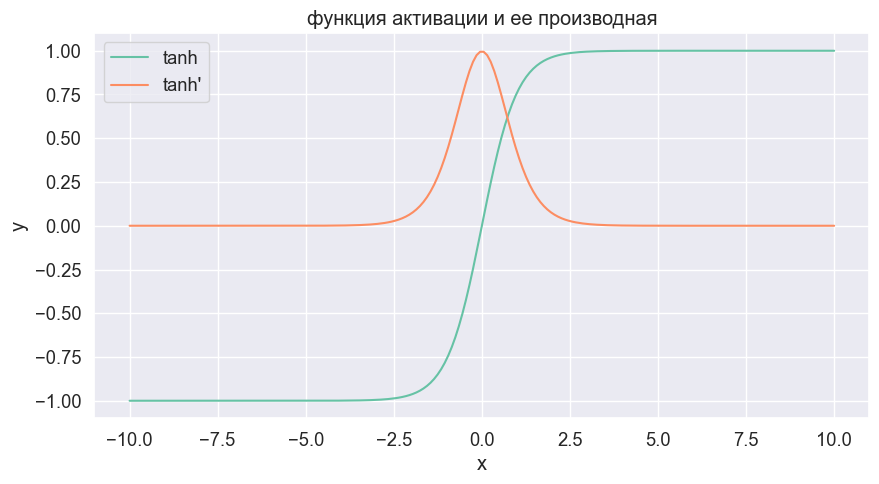

In [250]:
plt.figure(figsize=(10, 5))
x = np.linspace(-10, 10, 200)
func_activate = np.tanh(x)
plt.plot(x, func_activate, label = 'tanh')
grad_func_activate = np.gradient(func_activate, x)
plt.plot(x, grad_func_activate, label = "tanh'")
plt.title("функция активации и ее производная")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

На основе графика проанализируйте, что будет происходить с градиентом по весам первого слоя, если нейросеть "ненулевая", иначе говоря, на промежуточных слоях может выдавать различные значения, в том числе довольно большие.

каждый раз функция активации "нормирует" значения в нейронах подобно сигмоиде, не позволяя им стаь очень большими. Так как она лежит в диапазоне (-1, 1).

**2.** Реализуйте эту нейросеть на **PyTorch**.

*Примечание.* Каждый слой должен быть инициализирован отдельно. Нельзя создавать копии уже инициализированного слоя. Можно использовать `nn.Sequential`.

In [271]:
# При реализации нейросети запрещено пользоваться ИИ-инструментами.

layers = [nn.Linear(14 * 14, 32)]
for i in range(98):
  layers.append(nn.Tanh())
  layers.append(nn.Linear(32, 32))
layers.append(nn.Tanh())
layers.append(nn.Linear(32, 1))

model_100 = nn.Sequential(*layers)

Обучите эту нейросеть для классификации изображений **с цифрами 0 и 1** из датасета MNIST с картинками размера **14x14**. Возможно, большой батч не поместится в память, поэтому предлагается использовать случайную подвыборку (батч) размера 32 на каждом шаге обучения:
```
idx = np.random.choice(len(x_train), 32)
x_batch = x_train[idx]
```

Визуализируйте лоссы и метрики во время обучения также как в задаче 1, на обучающей и тестовой выборках.

In [291]:
# проведем фильтрацмю по 0 или 1
mask = (train_labels == 1) | (train_labels == 0)

train_images_binary = train_images[mask]
train_labels_binary = train_labels[mask]

mask = (test_labels == 1) | (test_labels == 0)

test_images_binary = test_images[mask]
test_labels_binary = test_labels[mask]


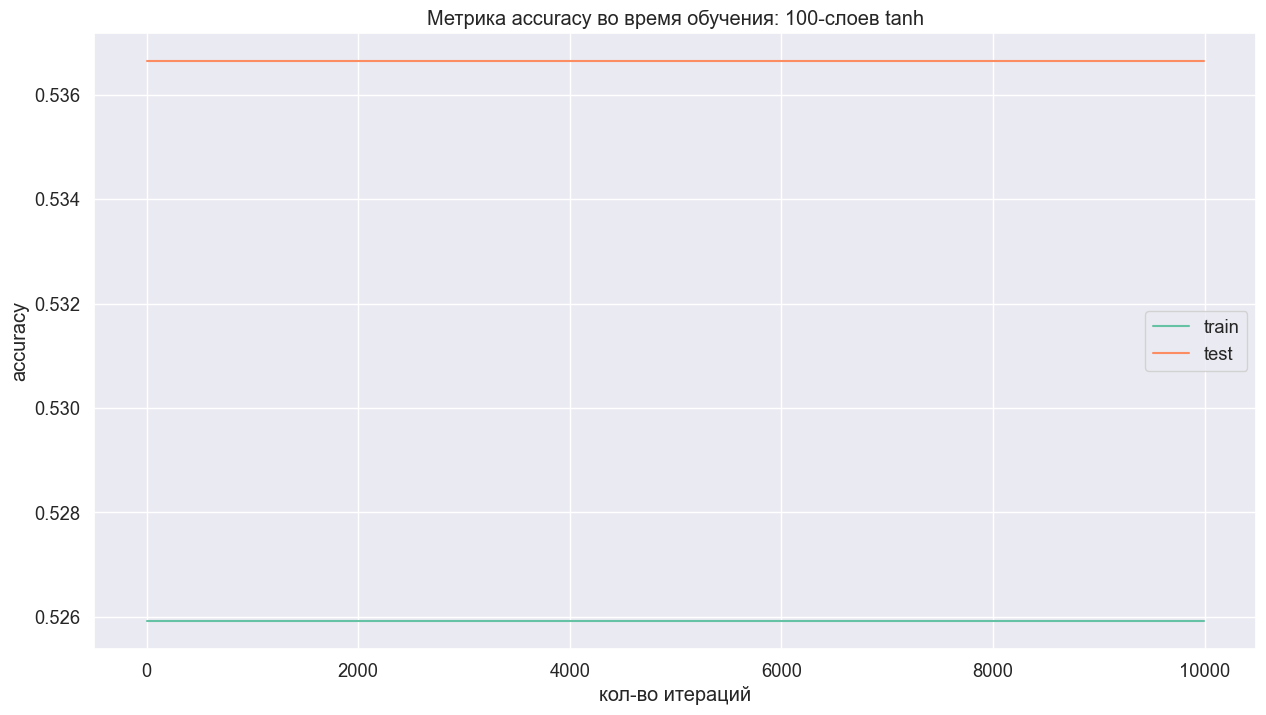

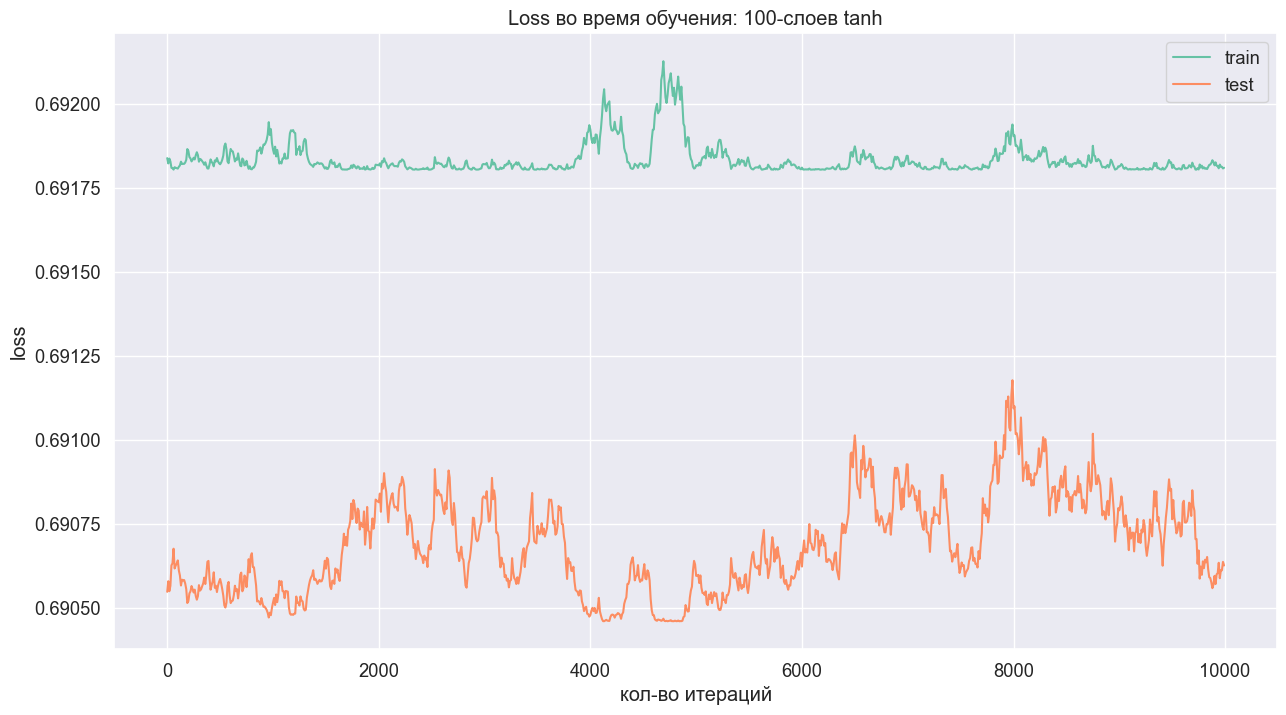

In [293]:
def train_model_bin(model, train_images, train_labels, test_images, test_labels,
                num_iter=10000, lr=0.05, model_name="model"):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': [],
        'iters': []
    }

    for i in range(num_iter):

        # создаем случайный батч
        idx = np.random.choice(len(train_images), 32)

        x_batch_train = train_images[idx]
        x_batch_train_labels = train_labels[idx].reshape(-1, 1).float()

        logits = model(x_batch_train)
        loss = loss_fn(logits, x_batch_train_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            clear_output(wait=True)

            train_logits = model(train_images)
            test_logits = model(test_images)

            train_labels_float = train_labels.reshape(-1, 1).float()
            test_labels_float = test_labels.reshape(-1, 1).float()

            train_loss = loss_fn(train_logits, train_labels_float).item()
            test_loss = loss_fn(test_logits, test_labels_float).item()

            train_pred = (train_logits > 0).float().reshape(-1)
            test_pred = (test_logits > 0).float().reshape(-1)

            train_acc = (train_pred == train_labels).float().mean().item()
            test_acc = (test_pred == test_labels).float().mean().item()

            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            history['iters'].append(i)

            plt.figure(figsize=(15, 8))
            plt.plot(history['iters'], history['train_acc'], label='train')
            plt.plot(history['iters'], history['test_acc'], label='test')
            plt.ylabel('accuracy')
            plt.xlabel('кол-во итераций')
            plt.legend()
            plt.title(f"Метрика accuracy во время обучения: {model_name}")
            plt.show()

            plt.figure(figsize=(15, 8))
            plt.plot(history['iters'], history['train_loss'], label='train')
            plt.plot(history['iters'], history['test_loss'], label='test')
            plt.ylabel('loss')
            plt.xlabel('кол-во итераций')
            plt.legend()
            plt.title(f"Loss во время обучения: {model_name}")
            plt.show()

    return history

history = train_model_bin(
    model_100,
    train_images_binary, train_labels_binary,
    test_images_binary, test_labels_binary,
    num_iter=10000,
    lr=0.005,
    model_name="100-слоев tanh"
)

Постройте график зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя от номера слоя.

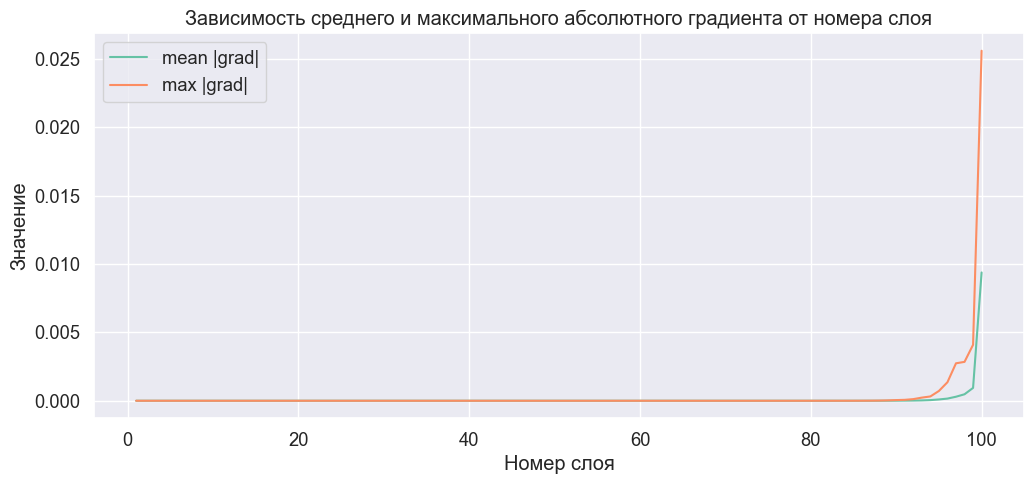

In [294]:
model_100.zero_grad()

idx = np.random.choice(len(train_images_binary), 32)
x_batch = train_images_binary[idx]
y_batch = train_labels_binary[idx].reshape(-1, 1).float()

logits = model_100(x_batch)
loss = nn.BCEWithLogitsLoss()(logits, y_batch)
loss.backward()

mean_abs_grads = []
max_abs_grads = []
layer_nums = []

layer_id = 1
for layer in model_100:
    if isinstance(layer, nn.Linear):
        grad = layer.weight.grad.detach()
        mean_abs_grads.append(grad.abs().mean().item())
        max_abs_grads.append(grad.abs().max().item())
        layer_nums.append(layer_id)
        layer_id += 1

plt.figure(figsize=(12, 5))
plt.plot(layer_nums, mean_abs_grads, label='mean |grad|')
plt.plot(layer_nums, max_abs_grads, label='max |grad|')
plt.xlabel('Номер слоя')
plt.ylabel('Значение')
plt.title('Зависимость среднего и максимального абсолютного градиента от номера слоя')
plt.legend()
plt.show()

На таком же датасете с обучите двухслойную нейронную сеть. Для консистентности также используйте батч размера 32. Визуализируйте лоссы и метрики во время обучения. Сравните результаты.

In [325]:
model_bin = nn.Sequential(
  nn.Linear(14 * 14, 32),
  nn.Tanh(),
  nn.Linear(32, 1)
)

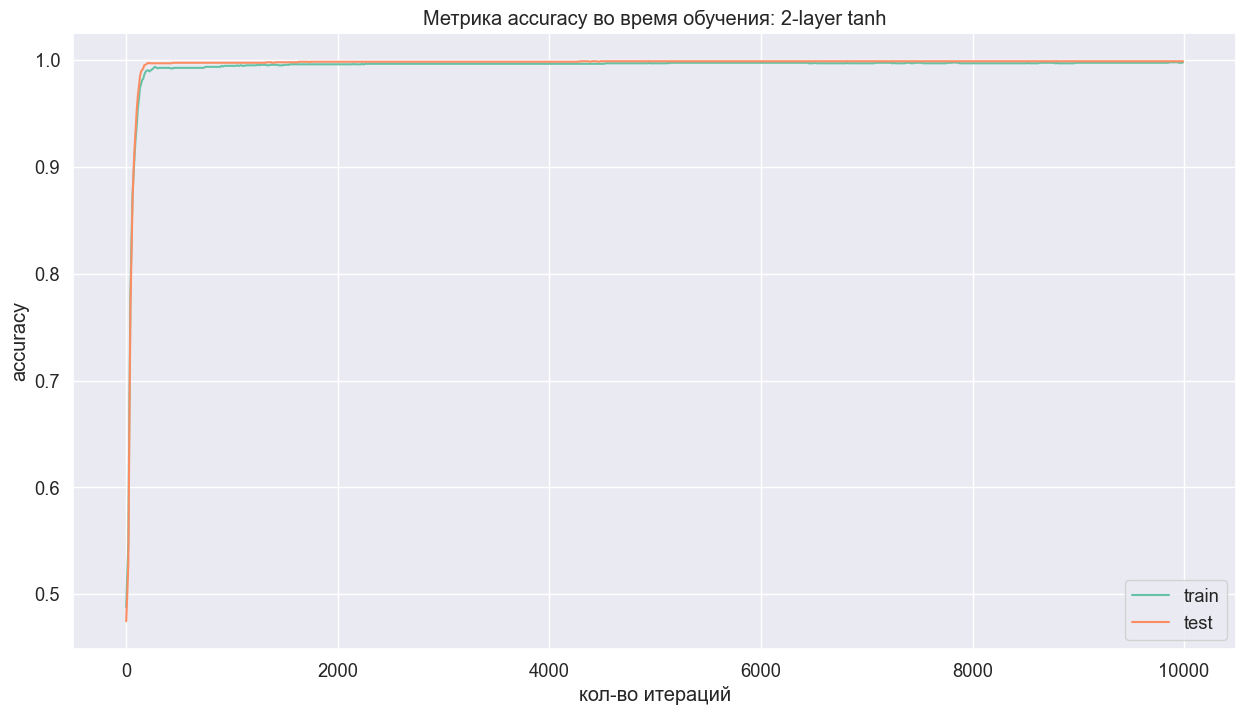

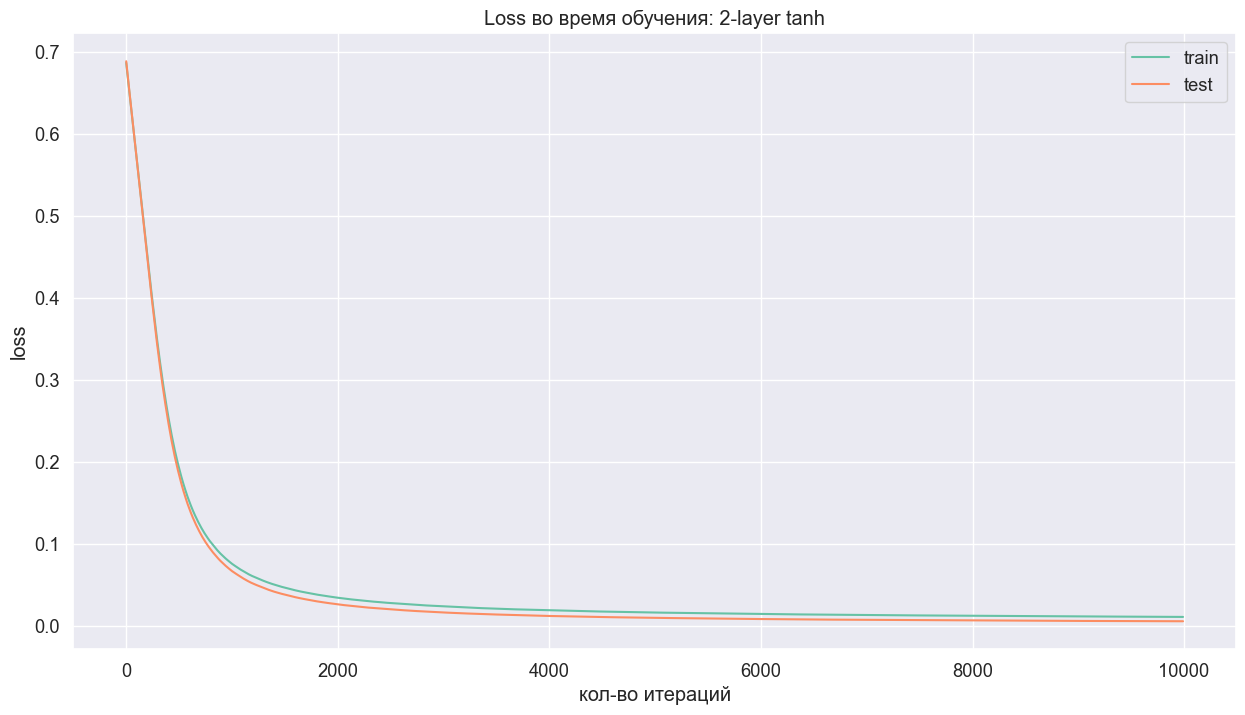

In [326]:
history = train_model_bin(
    model_bin,
    train_images_binary, train_labels_binary,
    test_images_binary, test_labels_binary,
    num_iter=10000,
    lr = 0.005,
    model_name="2-layer tanh"
)

In [327]:
print('Итоговая train accuracy:', history['train_acc'][-1])
print('Итоговая test accuracy:', history['test_acc'][-1])

Итоговая train accuracy: 0.9980979561805725
Итоговая test accuracy: 0.9990543723106384


**Выводы:**

Модель обученная на 100 слоях получилось почти постоянной в том смысле, что она почти всегда для всех обьектов выдает одно и тоже прдексазание. Это связано с функцией активации tanh, она для всех почти всех x переводит нейрон в значение (-1, 1) при насыщении функции. Это приводит к тому, что итоговый логит получаеься просто константный, то есть модель просто предсказыавает самый частыцй класс и вообще не зависит от входных параметров. И коореткность равна примерно 50%

Кроме того, так как градиент лосса по весам выражается через градинт на каждом слое, а градиаент на каждом слое (большем 2-ух) как мы видим из графика почти 0, то итоговый градиент тоже очень мал, поэтому оптимизаци очень нечувствительна к изначальным параметрам.

При этом, если оставить лишь 2 слоя, то аккуратность сильно вырастет, так как изначальаные данные не будут гасится слоями тангенсов

*Примечание.* Подобная ситуация известна как "паралич" нейросети. Именно поэтому такие функции активации, как ReLU, стали очень популярными. Для преодоления этого паралича существует множество методов, многие из которых мы рассмотрим на следующей лекции.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД

Постройте график зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя от номера слоя.